In [17]:
import cv2
import numpy as np
import glob
import os
import mediapipe as mp
import pickle

from mediapipe.tasks.python import vision
from mediapipe.tasks.python import BaseOptions

# ---------- CACHE FILES ----------
data_file = "blink_analysis_data.npz"
stats_file = "blink_analysis_stats.pkl"

# ---------- LOAD IF EXISTS ----------
if os.path.exists(data_file) and os.path.exists(stats_file):
    data = np.load(data_file)
    ear_series = data["ear_series"]
    timestamps = data["timestamps"]
    total_duration = float(data["duration_sec"])

    with open(stats_file, "rb") as f:
        blink_stats = pickle.load(f)

    analysis_output = {
        "ear_series": ear_series,
        "timestamps": timestamps,
        "blink_stats": blink_stats,
        "duration_sec": total_duration,
        "num_frames_used": int(len(ear_series)),
        "num_videos": None
    }

else:
    # ---------- COMPUTE ----------

    video_dir = "./videos/Jacob_Cartwright_Subject21"
    video_paths = sorted(glob.glob(os.path.join(video_dir, "*.[Mm][Pp]4")))
    video_paths = sorted(glob.glob(os.path.join(video_dir, "*.[Mm][Pp]4")))

    print(f"Found {len(video_paths)} videos")
    for i, p in enumerate(video_paths[:10]):
        print(f"{i+1}: {p}")

    if len(video_paths) > 10:
        print(f"... ({len(video_paths)-10} more)")

    model_path = "face_landmarker.task"

    options = vision.FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1
    )

    detector = vision.FaceLandmarker.create_from_options(options)

    LEFT_EYE = [33, 160, 158, 133, 153, 144]
    RIGHT_EYE = [362, 385, 387, 263, 373, 380]

    def eye_aspect_ratio(landmarks, eye_indices, w, h):
        pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in eye_indices]
        p1, p2, p3, p4, p5, p6 = pts
        vert1 = np.linalg.norm(np.array(p2) - np.array(p6))
        vert2 = np.linalg.norm(np.array(p3) - np.array(p5))
        horiz = np.linalg.norm(np.array(p1) - np.array(p4))
        return (vert1 + vert2) / (2.0 * horiz)

    ear_series = []
    timestamps = []

    global_time = 0.0
    total_duration = 0.0

    for video_path in video_paths:
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

        if fps == 0:
            continue

        video_duration = frame_count / fps
        total_duration += video_duration

        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            h, w = frame.shape[:2]

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

            result = detector.detect(mp_image)

            if result.face_landmarks:
                landmarks = result.face_landmarks[0]

                left_ear = eye_aspect_ratio(landmarks, LEFT_EYE, w, h)
                right_ear = eye_aspect_ratio(landmarks, RIGHT_EYE, w, h)
                ear = (left_ear + right_ear) / 2.0

                t = global_time + (frame_idx / fps)

                ear_series.append(ear)
                timestamps.append(t)

            frame_idx += 1

        global_time += video_duration
        cap.release()

    ear_series = np.array(ear_series)
    timestamps = np.array(timestamps)

    thresholds = np.linspace(0.15, 0.35, 25)

    blink_stats = {}

    if total_duration == 0:
        total_duration = 1

    for thresh in thresholds:
        blinks = 0
        closed = False

        for ear in ear_series:
            if ear < thresh and not closed:
                closed = True
                blinks += 1
            elif ear >= thresh:
                closed = False

        blink_rate = blinks / total_duration

        blink_stats[float(thresh)] = {
            "total_blinks": int(blinks),
            "blink_rate_per_sec": float(blink_rate)
        }

    analysis_output = {
        "ear_series": ear_series,
        "timestamps": timestamps,
        "blink_stats": blink_stats,
        "duration_sec": float(total_duration),
        "num_frames_used": int(len(ear_series)),
        "num_videos": int(len(video_paths))
    }

    # ---------- SAVE ----------
    np.savez_compressed(
        data_file,
        ear_series=ear_series,
        timestamps=timestamps,
        duration_sec=total_duration
    )

    with open(stats_file, "wb") as f:
        pickle.dump(blink_stats, f)

## Single time series analysis (Flattened)

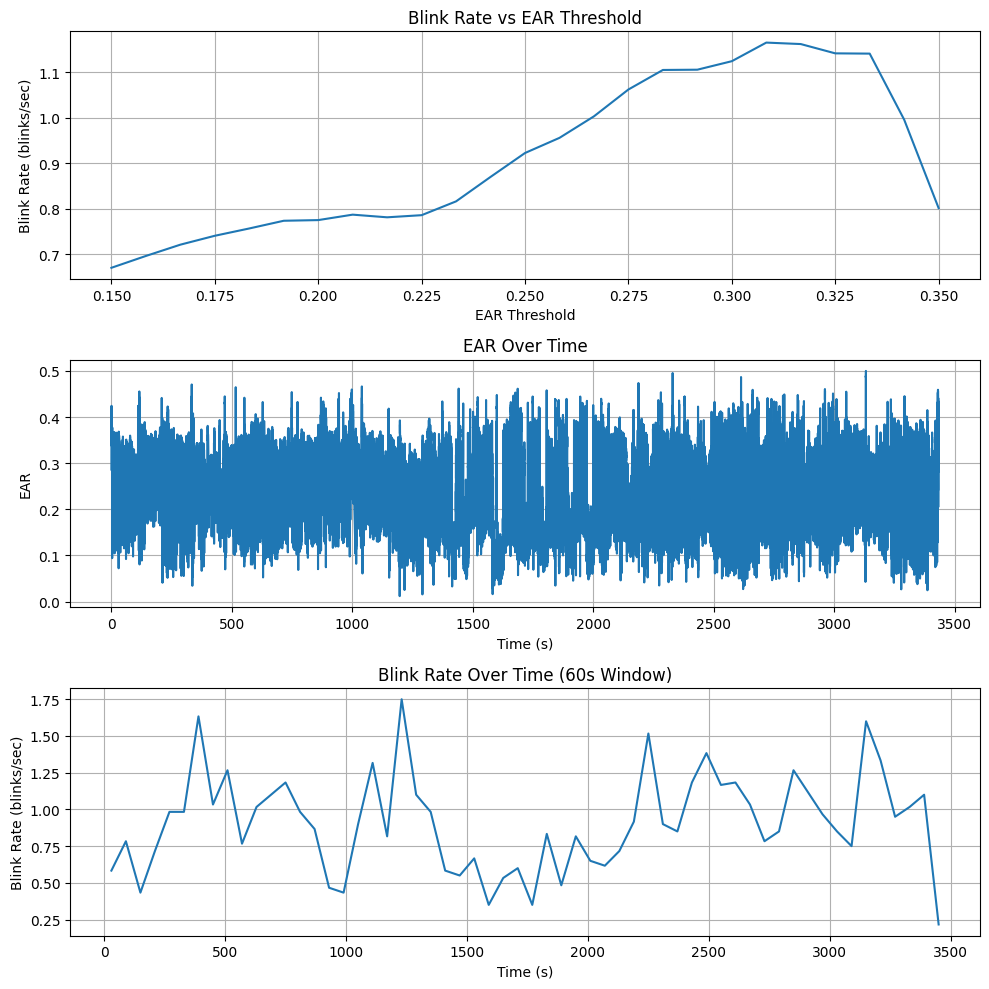

In [22]:
import numpy as np
import matplotlib.pyplot as plt

ear_series = analysis_output["ear_series"]
timestamps = analysis_output["timestamps"]
blink_stats = analysis_output["blink_stats"]
duration = analysis_output["duration_sec"]

thresholds = sorted(blink_stats.keys())
rates = [blink_stats[t]["blink_rate_per_sec"] for t in thresholds]

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# --- Threshold vs blink rate ---
axes[0].plot(thresholds, rates)
axes[0].set_xlabel("EAR Threshold")
axes[0].set_ylabel("Blink Rate (blinks/sec)")
axes[0].set_title("Blink Rate vs EAR Threshold")
axes[0].grid(True)

# --- EAR over time ---
axes[1].plot(timestamps, ear_series)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("EAR")
axes[1].set_title("EAR Over Time")
axes[1].grid(True)

# --- Blink rate over time ---
window_sec = 60
window_edges = np.arange(0, duration + window_sec, window_sec)

thresh = thresholds[len(thresholds)//2]

blink_times = []
closed = False

for i, ear in enumerate(ear_series):
    if ear < thresh and not closed:
        closed = True
        blink_times.append(timestamps[i])
    elif ear >= thresh:
        closed = False

blink_times = np.array(blink_times)

window_rates = []
window_centers = []

for i in range(len(window_edges)-1):
    start = window_edges[i]
    end = window_edges[i+1]
    count = np.sum((blink_times >= start) & (blink_times < end))
    rate = count / (end - start)
    window_rates.append(rate)
    window_centers.append((start + end)/2)

axes[2].plot(window_centers, window_rates)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Blink Rate (blinks/sec)")
axes[2].set_title("Blink Rate Over Time (60s Window)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [24]:
threshold = 0.225

# handle float key mismatch safely
closest_threshold = min(blink_stats.keys(), key=lambda x: abs(x - threshold))
final_rate = blink_stats[closest_threshold]["blink_rate_per_sec"]

print(f"Average blink rate (threshold={closest_threshold}): {final_rate:.4f} blinks/sec")

Average blink rate (threshold=0.22499999999999998): 0.7862 blinks/sec


## Blink Rate Interpretation

The measured blink rate appears elevated relative to typical baseline values. However, qualitative inspection of the source video confirms that this estimate is consistent with observed behavior. During recording, the subject was adapting to contact lenses, which resulted in an unusually high blink frequency while adjusting to the sensation.

****

## Group-wise Analysis


--- PER-VIDEO SUMMARY ---



,Video,Duration (s),Blink Count,Blink Rate (blinks/sec),Mean EAR,Std EAR
0,GX011166.MP4,112.41,78,0.69,0.30,0.06
1,GX011167.MP4,97.10,41,0.42,0.33,0.05
2,GX011169.MP4,122.09,126,1.03,0.27,0.09
3,GX011170.MP4,137.77,174,1.26,0.27,0.06
4,GX011171.MP4,157.16,152,0.97,0.27,0.08
5,GX011172.MP4,144.94,169,1.17,0.27,0.07
6,GX011173.MP4,106.67,96,0.90,0.30,0.06
7,GX011174.MP4,111.48,66,0.59,0.31,0.06
8,GX011175.MP4,158.16,151,0.95,0.29,0.06
9,GX011176.MP4,224.36,264,1.18,0.27,0.07



--- FILTERING NOTE ---

Videos shorter than 5 seconds were excluded from the group-wise analysis and plots.
Excluded 2 video(s).
Excluded files:
  - GX011168.MP4
  - GX011187.MP4


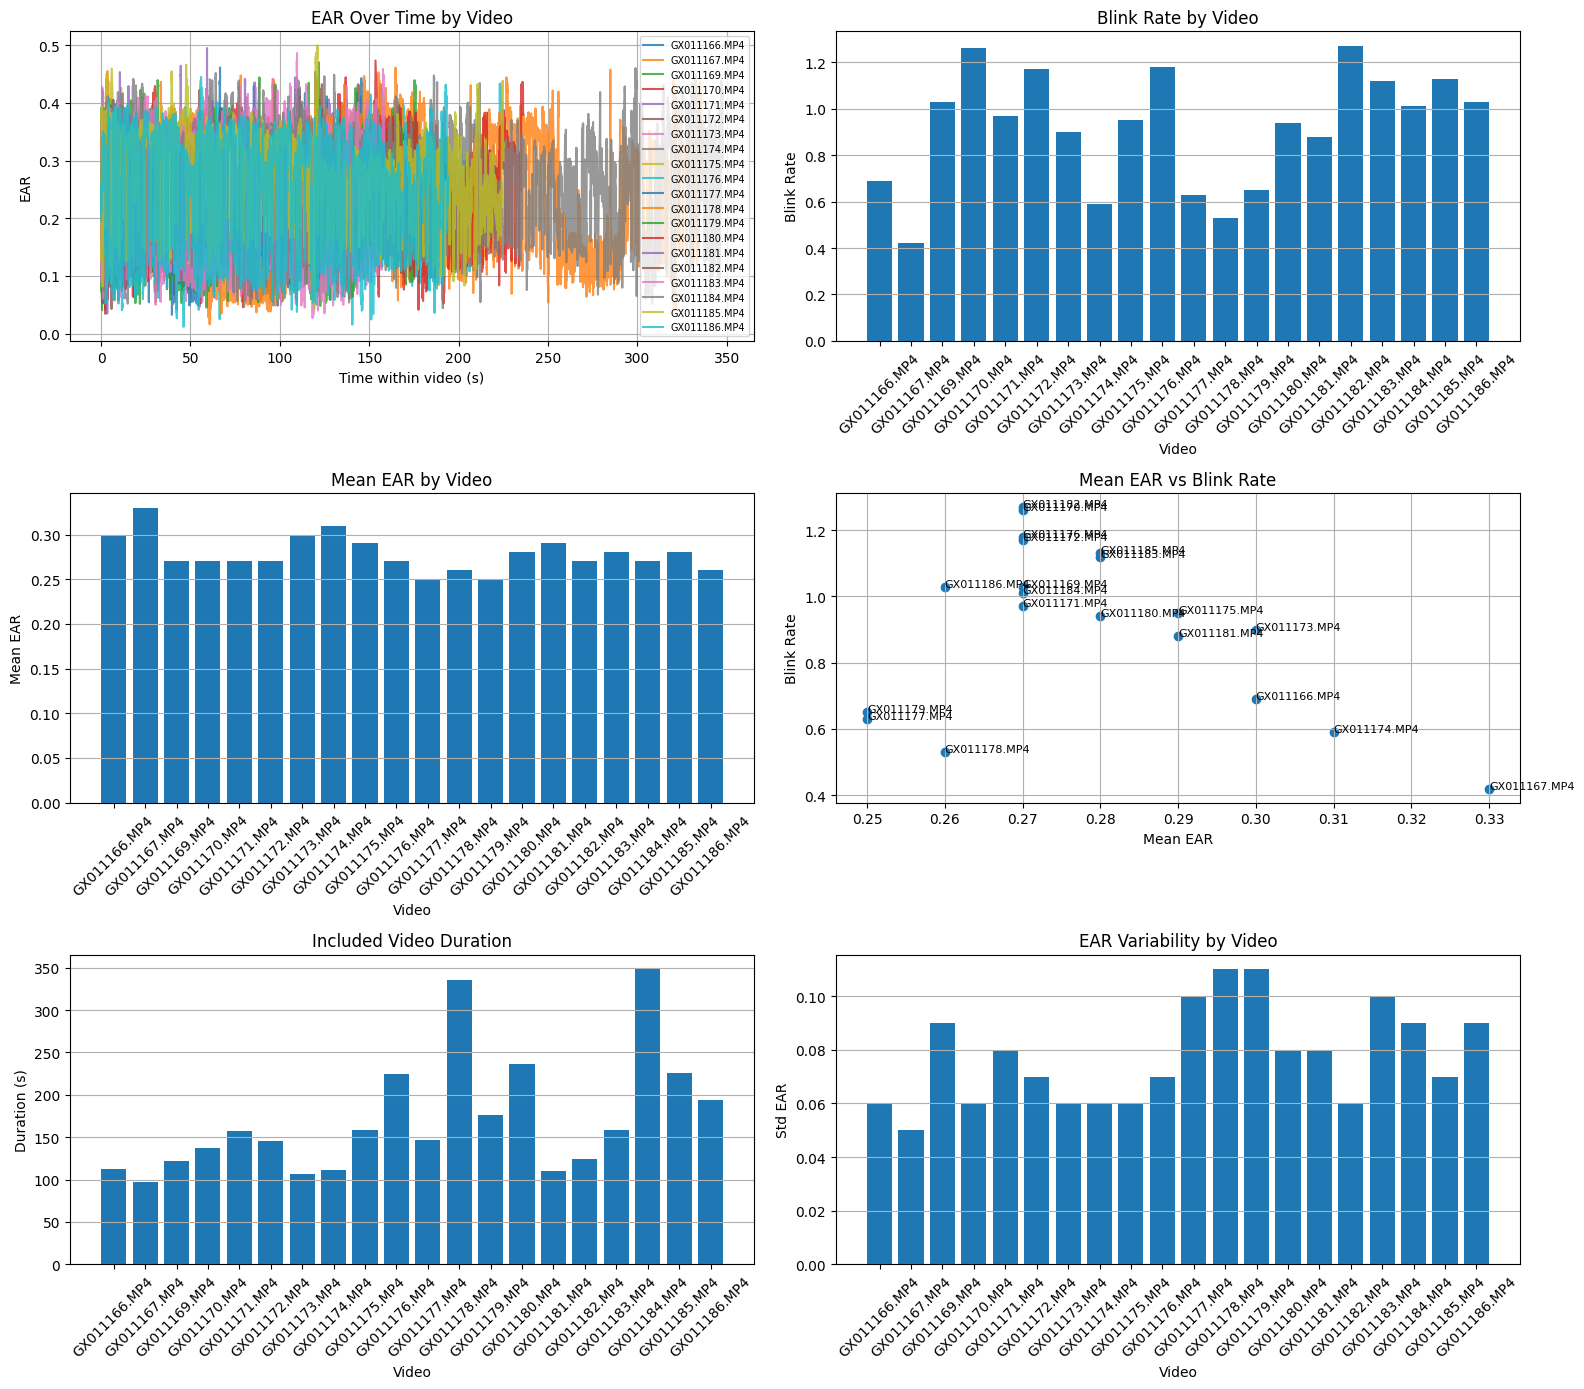

In [19]:
import numpy as np
import cv2
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

# ---------- LOAD PATHS ----------
video_dir = "./videos/Jacob_Cartwright_Subject21"
video_paths = sorted(glob.glob(os.path.join(video_dir, "*.[Mm][Pp]4")))
video_names = [os.path.basename(p) for p in video_paths]

# ---------- RECONSTRUCT VIDEO BOUNDARIES ----------
video_durations = []

for p in video_paths:
    cap = cv2.VideoCapture(p)
    if not cap.isOpened():
        video_durations.append(0)
        continue
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    video_durations.append(frames / fps if fps > 0 else 0)

video_durations = np.array(video_durations)
video_start_times = np.concatenate([[0], np.cumsum(video_durations)[:-1]])
video_end_times = np.cumsum(video_durations)

# ---------- LOAD DATA ----------
timestamps = np.array(analysis_output["timestamps"])
ear_series = np.array(analysis_output["ear_series"])

video_ids = np.zeros_like(timestamps, dtype=int)

for i, (start, end) in enumerate(zip(video_start_times, video_end_times)):
    mask = (timestamps >= start) & (timestamps < end)
    video_ids[mask] = i

# ---------- GROUP ANALYSIS ----------
thresholds = sorted(analysis_output["blink_stats"].keys())
thresh = thresholds[len(thresholds) // 2]

rows = []
excluded_videos = []

for vid in range(len(video_paths)):
    mask = video_ids == vid
    if np.sum(mask) == 0:
        excluded_videos.append(video_names[vid])
        continue

    ear_v = ear_series[mask]
    time_v = timestamps[mask]

    duration_v = time_v[-1] - time_v[0]
    if duration_v < 5:
        excluded_videos.append(video_names[vid])
        continue

    blink_times = []
    closed = False

    for i, ear in enumerate(ear_v):
        if ear < thresh and not closed:
            closed = True
            blink_times.append(time_v[i])
        elif ear >= thresh:
            closed = False

    blink_count = len(blink_times)
    blink_rate = blink_count / duration_v if duration_v > 0 else np.nan

    rows.append({
        "Video": video_names[vid],
        "Duration (s)": duration_v,
        "Blink Count": blink_count,
        "Blink Rate (blinks/sec)": blink_rate,
        "Mean EAR": np.mean(ear_v),
        "Std EAR": np.std(ear_v)
    })

group_df = pd.DataFrame(rows).round(2)

print("\n--- PER-VIDEO SUMMARY ---\n")
display(group_df)

print("\n--- FILTERING NOTE ---\n")
print("Videos shorter than 5 seconds were excluded from the group-wise analysis and plots.")
print(f"Excluded {len(excluded_videos)} video(s).")
if excluded_videos:
    print("Excluded files:")
    for name in excluded_videos:
        print(f"  - {name}")

# ---------- PLOTS ----------
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

included_videos = set(group_df["Video"])

# EAR traces
for vid in range(len(video_paths)):
    if video_names[vid] not in included_videos:
        continue
    mask = video_ids == vid
    if np.sum(mask) == 0:
        continue
    t_local = timestamps[mask] - video_start_times[vid]
    axes[0, 0].plot(t_local, ear_series[mask], label=video_names[vid], alpha=0.8)

axes[0, 0].set_xlabel("Time within video (s)")
axes[0, 0].set_ylabel("EAR")
axes[0, 0].set_title("EAR Over Time by Video")
axes[0, 0].grid(True)
axes[0, 0].legend(fontsize=7)

# Blink rate bar
axes[0, 1].bar(group_df["Video"], group_df["Blink Rate (blinks/sec)"])
axes[0, 1].set_xlabel("Video")
axes[0, 1].set_ylabel("Blink Rate")
axes[0, 1].set_title("Blink Rate by Video")
axes[0, 1].grid(axis="y")
axes[0, 1].tick_params(axis="x", rotation=45)

# Mean EAR bar
axes[1, 0].bar(group_df["Video"], group_df["Mean EAR"])
axes[1, 0].set_xlabel("Video")
axes[1, 0].set_ylabel("Mean EAR")
axes[1, 0].set_title("Mean EAR by Video")
axes[1, 0].grid(axis="y")
axes[1, 0].tick_params(axis="x", rotation=45)

# Scatter
axes[1, 1].scatter(group_df["Mean EAR"], group_df["Blink Rate (blinks/sec)"])
for _, row in group_df.iterrows():
    axes[1, 1].annotate(
        row["Video"],
        (row["Mean EAR"], row["Blink Rate (blinks/sec)"]),
        fontsize=8
    )

axes[1, 1].set_xlabel("Mean EAR")
axes[1, 1].set_ylabel("Blink Rate")
axes[1, 1].set_title("Mean EAR vs Blink Rate")
axes[1, 1].grid(True)

# NEW: Duration by video
axes[2, 0].bar(group_df["Video"], group_df["Duration (s)"])
axes[2, 0].set_xlabel("Video")
axes[2, 0].set_ylabel("Duration (s)")
axes[2, 0].set_title("Included Video Duration")
axes[2, 0].grid(axis="y")
axes[2, 0].tick_params(axis="x", rotation=45)

# NEW: EAR variability by video
axes[2, 1].bar(group_df["Video"], group_df["Std EAR"])
axes[2, 1].set_xlabel("Video")
axes[2, 1].set_ylabel("Std EAR")
axes[2, 1].set_title("EAR Variability by Video")
axes[2, 1].grid(axis="y")
axes[2, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Face Measurements

,Measurement,Mean,Std
0,Face Height (×IPD),2.74,0.15
1,"Face Height (cm, IPD)",16.42,0.92
2,"Face Height (cm, Iris)",16.86,1.49
3,Face Width (×IPD),2.21,0.07
4,"Face Width (cm, IPD)",13.27,0.40
5,"Face Width (cm, Iris)",13.64,1.09
6,Left Eye Width (×IPD),0.44,0.02
7,"Left Eye Width (cm, IPD)",2.63,0.11
8,"Left Eye Width (cm, Iris)",2.70,0.21
9,Left Eye Height (×IPD),0.14,0.05


,Video,Frame Index,Face Height (×IPD),"Face Height (cm, IPD)","Face Height (cm, Iris)",Face Width (×IPD),"Face Width (cm, IPD)","Face Width (cm, Iris)",Left Eye Width (×IPD),"Left Eye Width (cm, IPD)",...,"Nose Width (cm, IPD)","Nose Width (cm, Iris)",Mouth Width (×IPD),"Mouth Width (cm, IPD)","Mouth Width (cm, Iris)",Mouth Height (×IPD),"Mouth Height (cm, IPD)","Mouth Height (cm, Iris)",IPD (px),Iris Diameter (px)
0,GX011166.MP4,0,2.63,15.78,15.30,2.25,13.50,13.09,0.45,2.71,...,3.08,2.99,0.68,4.06,3.93,0.01,0.03,0.03,42.91,8.71
1,GX011166.MP4,10,2.74,16.41,15.82,2.19,13.15,12.68,0.44,2.65,...,3.07,2.96,0.74,4.43,4.27,0.01,0.04,0.04,41.34,8.43
2,GX011166.MP4,20,2.70,16.18,15.11,2.21,13.27,12.39,0.45,2.72,...,2.86,2.67,0.68,4.07,3.80,0.01,0.05,0.04,42.13,8.87
3,GX011166.MP4,30,2.74,16.44,16.00,2.17,13.02,12.67,0.44,2.61,...,3.21,3.12,0.71,4.24,4.13,0.01,0.04,0.04,41.45,8.38
4,GX011166.MP4,40,2.77,16.64,16.29,2.20,13.19,12.91,0.45,2.69,...,3.07,3.01,0.69,4.13,4.04,0.01,0.04,0.04,41.70,8.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,GX011187.MP4,60,2.68,16.09,15.62,2.26,13.54,13.14,0.43,2.58,...,3.53,3.42,0.75,4.48,4.35,0.00,0.01,0.01,37.75,7.65
512,GX011187.MP4,70,2.93,17.55,16.15,2.22,13.32,12.25,0.42,2.50,...,3.18,2.93,0.73,4.37,4.02,0.01,0.04,0.03,35.62,7.62
513,GX011187.MP4,80,2.93,17.59,17.05,2.34,14.07,13.63,0.45,2.67,...,2.99,2.90,0.71,4.25,4.12,0.00,0.02,0.02,32.85,6.67
514,GX011187.MP4,90,2.80,16.80,18.06,2.18,13.08,14.07,0.43,2.60,...,3.10,3.34,0.74,4.42,4.76,0.01,0.09,0.09,33.27,6.09


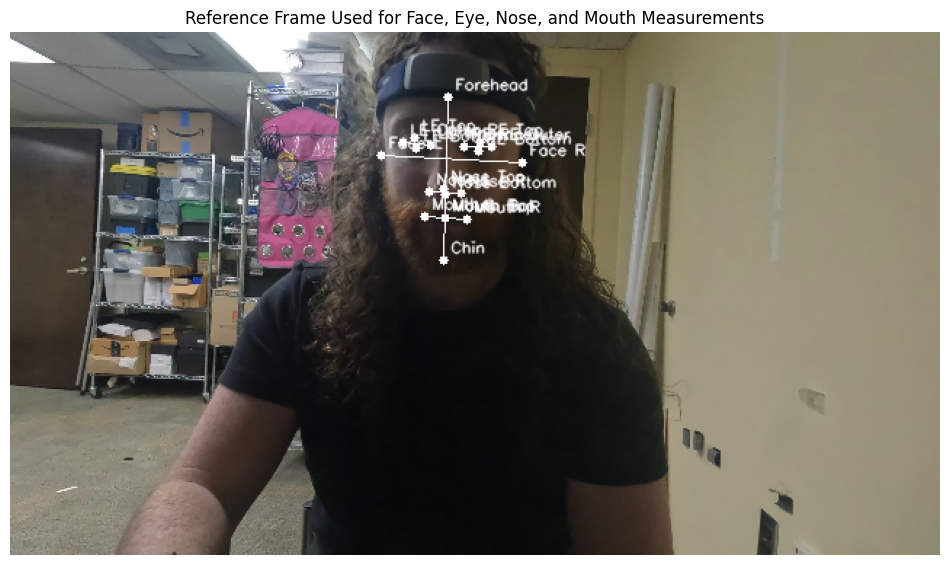

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from mediapipe.tasks.python import vision
from mediapipe.tasks.python import BaseOptions

# ---------- PATH ----------
video_dir = "./videos/Jacob_Cartwright_Subject21"
video_paths = sorted(glob.glob(os.path.join(video_dir, "*.[Mm][Pp]4")))

# ---------- MODEL ----------
model_path = "face_landmarker.task"

options = vision.FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    num_faces=1
)

detector = vision.FaceLandmarker.create_from_options(options)

# ---------- CONSTANTS ----------
known_ipd_cm = 6.0 # measured distance between my eyes
known_iris_cm = 1.18 # Width of the average Iris

LEFT_EYE_CENTER = 468
RIGHT_EYE_CENTER = 473

FOREHEAD = 10
CHIN = 152
LEFT_FACE = 234
RIGHT_FACE = 454

NOSE_TOP = 1
NOSE_BOTTOM = 2
NOSE_LEFT = 98
NOSE_RIGHT = 327

MOUTH_LEFT = 61
MOUTH_RIGHT = 291
MOUTH_TOP = 13
MOUTH_BOTTOM = 14

LEFT_EYE_OUTER = 33
LEFT_EYE_INNER = 133
LEFT_EYE_TOP = 159
LEFT_EYE_BOTTOM = 145

RIGHT_EYE_OUTER = 263
RIGHT_EYE_INNER = 362
RIGHT_EYE_TOP = 386
RIGHT_EYE_BOTTOM = 374

LEFT_IRIS = [468, 469, 470, 471, 472]
RIGHT_IRIS = [473, 474, 475, 476, 477]

# ---------- HELPERS ----------
def get_point(landmarks, idx, w, h):
    return np.array([landmarks[idx].x * w, landmarks[idx].y * h], dtype=np.float32)

def dist(a, b):
    return float(np.linalg.norm(a - b))

def iris_diameter(landmarks, idxs, w, h):
    pts = [get_point(landmarks, i, w, h) for i in idxs]
    return max(dist(a, b) for a in pts for b in pts)

def add_measurement(record, name, px_value, ipd_px, ipd_scale, iris_scale):
    record[f"{name} (×IPD)"] = px_value / ipd_px
    record[f"{name} (cm, IPD)"] = px_value * ipd_scale
    record[f"{name} (cm, Iris)"] = px_value * iris_scale if np.isfinite(iris_scale) else np.nan

# ---------- STORAGE ----------
all_measurements = []
example_frame = None
example_landmarks = None

# ---------- SAMPLING ----------
frame_stride = 10
max_samples_per_video = 25

for video_path in video_paths:
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    samples_taken = 0

    while samples_taken < max_samples_per_video:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_stride != 0:
            frame_idx += 1
            continue

        frame = cv2.resize(frame, (640, 360))
        h, w = frame.shape[:2]

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_image)

        if result.face_landmarks:
            lm = result.face_landmarks[0]

            if example_frame is None:
                example_frame = frame.copy()
                example_landmarks = lm

            left_eye_center = get_point(lm, LEFT_EYE_CENTER, w, h)
            right_eye_center = get_point(lm, RIGHT_EYE_CENTER, w, h)
            ipd_px = dist(left_eye_center, right_eye_center)

            if ipd_px <= 0:
                frame_idx += 1
                continue

            left_iris_px = iris_diameter(lm, LEFT_IRIS, w, h)
            right_iris_px = iris_diameter(lm, RIGHT_IRIS, w, h)
            iris_px = np.mean([left_iris_px, right_iris_px])

            ipd_scale = known_ipd_cm / ipd_px
            iris_scale = known_iris_cm / iris_px if iris_px > 0 else np.nan

            face_height_px = dist(get_point(lm, FOREHEAD, w, h), get_point(lm, CHIN, w, h))
            face_width_px = dist(get_point(lm, LEFT_FACE, w, h), get_point(lm, RIGHT_FACE, w, h))

            nose_length_px = dist(get_point(lm, NOSE_TOP, w, h), get_point(lm, NOSE_BOTTOM, w, h))
            nose_width_px = dist(get_point(lm, NOSE_LEFT, w, h), get_point(lm, NOSE_RIGHT, w, h))

            mouth_width_px = dist(get_point(lm, MOUTH_LEFT, w, h), get_point(lm, MOUTH_RIGHT, w, h))
            mouth_height_px = dist(get_point(lm, MOUTH_TOP, w, h), get_point(lm, MOUTH_BOTTOM, w, h))

            left_eye_width_px = dist(get_point(lm, LEFT_EYE_OUTER, w, h), get_point(lm, LEFT_EYE_INNER, w, h))
            left_eye_height_px = dist(get_point(lm, LEFT_EYE_TOP, w, h), get_point(lm, LEFT_EYE_BOTTOM, w, h))

            right_eye_width_px = dist(get_point(lm, RIGHT_EYE_OUTER, w, h), get_point(lm, RIGHT_EYE_INNER, w, h))
            right_eye_height_px = dist(get_point(lm, RIGHT_EYE_TOP, w, h), get_point(lm, RIGHT_EYE_BOTTOM, w, h))

            avg_eye_width_px = np.mean([left_eye_width_px, right_eye_width_px])
            avg_eye_height_px = np.mean([left_eye_height_px, right_eye_height_px])

            row = {
                "Video": os.path.basename(video_path),
                "Frame Index": frame_idx
            }

            add_measurement(row, "Face Height", face_height_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Face Width", face_width_px, ipd_px, ipd_scale, iris_scale)

            add_measurement(row, "Left Eye Width", left_eye_width_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Left Eye Height", left_eye_height_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Right Eye Width", right_eye_width_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Right Eye Height", right_eye_height_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Average Eye Width", avg_eye_width_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Average Eye Height", avg_eye_height_px, ipd_px, ipd_scale, iris_scale)

            add_measurement(row, "Nose Length", nose_length_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Nose Width", nose_width_px, ipd_px, ipd_scale, iris_scale)

            add_measurement(row, "Mouth Width", mouth_width_px, ipd_px, ipd_scale, iris_scale)
            add_measurement(row, "Mouth Height", mouth_height_px, ipd_px, ipd_scale, iris_scale)

            row["IPD (px)"] = ipd_px
            row["Iris Diameter (px)"] = iris_px

            all_measurements.append(row)
            samples_taken += 1

        frame_idx += 1

    cap.release()

# ---------- DATAFRAMES ----------
raw_measurements = pd.DataFrame(all_measurements)

if raw_measurements.empty:
    raise ValueError("No face measurements were collected. Check the video path, model file, or landmark detection.")

measurement_columns = [
    c for c in raw_measurements.columns
    if c not in ["Video", "Frame Index"]
]

summary = pd.DataFrame({
    "Measurement": measurement_columns,
    "Mean": raw_measurements[measurement_columns].mean(),
    "Std": raw_measurements[measurement_columns].std()
}).reset_index(drop=True)

raw_measurements = raw_measurements.round(2)
summary["Mean"] = summary["Mean"].round(2)
summary["Std"] = summary["Std"].round(2)

# ---------- SHOW MEASUREMENTS ----------
display(summary)
display(raw_measurements)

# ---------- VISUALIZATION ----------
if example_frame is not None:
    img = example_frame.copy()
    h, w = img.shape[:2]

    def draw_point(idx, label):
        p = get_point(example_landmarks, idx, w, h).astype(int)
        cv2.circle(img, tuple(p), 3, (255, 255, 255), -1)
        cv2.putText(
            img,
            label,
            (int(p[0] + 5), int(p[1] - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    def draw_line(idx1, idx2):
        p1 = get_point(example_landmarks, idx1, w, h).astype(int)
        p2 = get_point(example_landmarks, idx2, w, h).astype(int)
        cv2.line(img, tuple(p1), tuple(p2), (255, 255, 255), 1)

    draw_line(FOREHEAD, CHIN)
    draw_line(LEFT_FACE, RIGHT_FACE)

    draw_line(LEFT_EYE_OUTER, LEFT_EYE_INNER)
    draw_line(LEFT_EYE_TOP, LEFT_EYE_BOTTOM)
    draw_line(RIGHT_EYE_OUTER, RIGHT_EYE_INNER)
    draw_line(RIGHT_EYE_TOP, RIGHT_EYE_BOTTOM)

    draw_line(NOSE_TOP, NOSE_BOTTOM)
    draw_line(NOSE_LEFT, NOSE_RIGHT)

    draw_line(MOUTH_LEFT, MOUTH_RIGHT)
    draw_line(MOUTH_TOP, MOUTH_BOTTOM)

    point_labels = {
        FOREHEAD: "Forehead",
        CHIN: "Chin",
        LEFT_FACE: "Face L",
        RIGHT_FACE: "Face R",
        LEFT_EYE_OUTER: "LE Outer",
        LEFT_EYE_INNER: "LE Inner",
        LEFT_EYE_TOP: "LE Top",
        LEFT_EYE_BOTTOM: "LE Bottom",
        RIGHT_EYE_OUTER: "RE Outer",
        RIGHT_EYE_INNER: "RE Inner",
        RIGHT_EYE_TOP: "RE Top",
        RIGHT_EYE_BOTTOM: "RE Bottom",
        NOSE_TOP: "Nose Top",
        NOSE_BOTTOM: "Nose Bottom",
        NOSE_LEFT: "Nose L",
        NOSE_RIGHT: "Nose R",
        MOUTH_LEFT: "Mouth L",
        MOUTH_RIGHT: "Mouth R",
        MOUTH_TOP: "Mouth Top",
        MOUTH_BOTTOM: "Mouth Bot",
    }

    for idx, label in point_labels.items():
        draw_point(idx, label)

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Reference Frame Used for Face, Eye, Nose, and Mouth Measurements")
    plt.show()

This pipeline extracts facial landmarks from sampled video frames and computes geometric distances between key points (chin, forehead, eyes, nose, and mouth) to estimate facial proportions and sizes. Measurements are expressed in three forms: scale-free ratios relative to interpupillary distance (×IPD), absolute sizes derived from an assumed IPD (cm, IPD), and absolute sizes derived from iris diameter (cm, Iris). The iris-based scaling uses a known population-average iris diameter (~1.18 cm) as a reference, while the IPD-based scaling instead uses a measured pixel distance between the eyes combined with an assumed real-world IPD. Together, these provide both normalized comparisons and approximate real-world dimensions, with the two scaling methods offering complementary assumptions about physical size .
